# RAG vs Vanilla LLM: Hallucination Evaluation on BBCSport

## Research Question
Does Retrieval-Augmented Generation (RAG) reduce hallucination compared to a vanilla LLM when answering factual questions about BBC sports news articles?

## Dataset
University College Dublin  mlg.ucd.ie/datasets/bbc.html

BBCSport — 737 raw text articles across 5 categories (athletics, cricket, football, rugby, tennis), 2004–2005.

## Pipeline Overview
1. Data Loading  
2. Corpus Preparation (chunking)  
3. Automatic QA Generation  
4. Vanilla LLM Evaluation  
5. RAG Implementation & Evaluation  
6. Metrics & Visualization  


## Section 0 — Install Dependencies
Run once if packages are not yet installed.

In [1]:
# !pip install openai faiss-cpu tiktoken pandas numpy matplotlib seaborn tqdm python-dotenv rank-bm25


## Section 1 — Setup & Imports

In [2]:
import os
import re
import json
import time
import random
import logging
import warnings
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tiktoken
import faiss
from openai import OpenAI

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('All imports successful.')


All imports successful.


### 1.1 Configuration & API Keys

In [3]:
from dotenv import load_dotenv

load_dotenv(dotenv_path='.env', override=True)
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not OPENAI_API_KEY or OPENAI_API_KEY.startswith('your-'):
    raise ValueError('Real API key not found. Set OPENAI_API_KEY in the .env file.')

client = OpenAI(api_key=OPENAI_API_KEY)

LLM_MODEL = "gpt-4o"
EMBEDDING_MODEL = 'text-embedding-3-small'
EMBEDDING_DIM = 1536

TOP_K_CHUNKS = 3
CHUNK_MIN_TOKENS = 300
CHUNK_MAX_TOKENS = 500
QA_TARGET_COUNT = 200

BBCSPORT_PATH = Path('bbcsport')

print(f'LLM model: {LLM_MODEL}')
print(f'Embedding model: {EMBEDDING_MODEL}')
print(f'BBCSport path: {BBCSPORT_PATH.resolve()}')
print('API key loaded from .env')


LLM model: gpt-4o
Embedding model: text-embedding-3-small
BBCSport path: C:\Users\rmadi\STATS 425\bbc kaggle\bbcsport
API key loaded from .env


---
## Section 2 — Data Loading

Recursively load all `.txt` files from the `bbcsport/` directory. Each sub-folder name becomes the article's category label.

In [4]:
CATEGORIES = ['athletics', 'cricket', 'football', 'rugby', 'tennis']


def load_bbcsport_articles(data_path: Path) -> pd.DataFrame:
    records = []
    for category in CATEGORIES:
        cat_path = data_path / category
        if not cat_path.exists():
            logger.warning(f'Missing directory: {cat_path}')
            continue
        txt_files = sorted(cat_path.glob('*.txt'))
        logger.info(f'{category}: {len(txt_files)} articles')
        for fp in txt_files:
            try:
                try:
                    text = fp.read_text(encoding='utf-8').strip()
                except UnicodeDecodeError:
                    text = fp.read_text(encoding='latin-1').strip()
                if text:
                    records.append({
                        'article_id': f'{category}_{fp.stem}',
                        'filename': fp.name,
                        'category': category,
                        'text': text,
                    })
            except Exception as e:
                logger.error(f'Failed to load {fp}: {e}')
    df = pd.DataFrame(records)
    logger.info(f'Total articles loaded: {len(df)}')
    return df


articles_df = load_bbcsport_articles(BBCSPORT_PATH)

print(f'Total articles: {len(articles_df)}')
print(articles_df['category'].value_counts().to_string())
print(f'Avg article length (chars): {articles_df["text"].str.len().mean():.0f}')
articles_df.head(3)


2026-03-01 16:26:58,298 - INFO - athletics: 101 articles
2026-03-01 16:26:59,150 - INFO - cricket: 124 articles
2026-03-01 16:27:00,228 - INFO - football: 265 articles
2026-03-01 16:27:02,495 - INFO - rugby: 147 articles
2026-03-01 16:27:03,743 - INFO - tennis: 100 articles
2026-03-01 16:27:04,617 - INFO - Total articles loaded: 737


Total articles: 737
category
football     265
rugby        147
cricket      124
athletics    101
tennis       100
Avg article length (chars): 1964


,article_id,filename,category,text
0,athletics_001,001.txt,athletics,Claxton hunting first major medal\n\nBritish h...
1,athletics_002,002.txt,athletics,O'Sullivan could run in Worlds\n\nSonia O'Sull...
2,athletics_003,003.txt,athletics,Greene sets sights on world title\n\nMaurice G...


---
## Section 3 — Corpus Preparation (Chunking)

Split each article into overlapping chunks of **300–500 tokens** (measured via `tiktoken`, the same tokeniser used by GPT models). This becomes the RAG retrieval corpus.

In [5]:
_TOKENIZER = tiktoken.encoding_for_model('gpt-3.5-turbo')


def count_tokens(text: str) -> int:
    return len(_TOKENIZER.encode(text))


def chunk_text(
    text: str,
    min_tokens: int = CHUNK_MIN_TOKENS,
    max_tokens: int = CHUNK_MAX_TOKENS,
) -> List[str]:
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    chunks: List[str] = []
    current: List[str] = []
    current_tok = 0

    for sent in sentences:
        sent = sent.strip()
        if not sent:
            continue
        sent_tok = count_tokens(sent)

        if sent_tok > max_tokens:
            if current:
                chunks.append(' '.join(current))
                current, current_tok = [], 0
            tokens = _TOKENIZER.encode(sent)
            for i in range(0, len(tokens), max_tokens):
                chunks.append(_TOKENIZER.decode(tokens[i:i + max_tokens]))
            continue

        if current_tok + sent_tok > max_tokens and current_tok >= min_tokens:
            chunks.append(' '.join(current))
            current, current_tok = [sent], sent_tok
        else:
            current.append(sent)
            current_tok += sent_tok

    if current:
        tail = ' '.join(current)
        if current_tok < min_tokens and chunks:
            merged = chunks[-1] + ' ' + tail
            if count_tokens(merged) <= int(max_tokens * 1.2):
                chunks[-1] = merged
            else:
                chunks.append(tail)
        else:
            chunks.append(tail)

    return chunks if chunks else [text]


def build_corpus(articles_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in tqdm(articles_df.iterrows(), total=len(articles_df), desc='Chunking articles'):
        for i, chunk in enumerate(chunk_text(row['text'])):
            records.append({
                'chunk_id': f"{row['article_id']}_c{i}",
                'chunk_text': chunk,
                'article_id': row['article_id'],
                'category': row['category'],
                'token_count': count_tokens(chunk),
            })
    df = pd.DataFrame(records)
    logger.info(f'Corpus: {len(df)} chunks from {len(articles_df)} articles')
    return df


corpus_df = build_corpus(articles_df)

print(f'Total chunks: {len(corpus_df)}')
print(f'Avg tokens / chunk: {corpus_df["token_count"].mean():.1f}')
print(f'Min / Max tokens: {corpus_df["token_count"].min()} / {corpus_df["token_count"].max()}')
corpus_df.head(3)


Chunking articles: 100%|██████████| 737/737 [00:00<00:00, 1300.14it/s]
2026-03-01 16:27:05,423 - INFO - Corpus: 903 chunks from 737 articles


Total chunks: 903
Avg tokens / chunk: 363.1
Min / Max tokens: 97 / 600


,chunk_id,chunk_text,article_id,category,token_count
0,athletics_001_c0,Claxton hunting first major medal\n\nBritish h...,athletics_001,athletics,277
1,athletics_002_c0,O'Sullivan could run in Worlds\n\nSonia O'Sull...,athletics_002,athletics,195
2,athletics_003_c0,Greene sets sights on world title\n\nMaurice G...,athletics_003,athletics,479


---
## Section 4 — Automatic QA Generation

Use GPT to generate ~200 **factual** QA pairs from sampled articles. Questions target extractable facts: team names, scores, player names, tournament names, match outcomes. Answers must be directly derivable from the article text (no inference required).

In [6]:
_QA_SYSTEM = (
    'You are a sports journalist fact-checker. Given a sports news article, '
    'generate factual question-answer pairs.\n\n'
    'Focus ONLY on facts explicitly stated in the article:\n'
    '- Team names and scores\n'
    '- Player names and specific actions\n'
    '- Tournament / competition names\n'
    '- Match outcomes\n'
    '- Specific numbers (goals, points, rankings, times)\n'
    '- Venues and dates when mentioned\n\n'
    'Rules:\n'
    '- Questions must be answerable ONLY from the article text\n'
    '- Answers must be specific and concise (1-6 words preferred)\n'
    '- Do NOT generate opinion or inference questions\n'
    '- Return ONLY valid JSON:\n'
    '{"qa_pairs": [{"question": "...", "answer": "..."}]}'
)


def generate_qa_for_article(
    text: str, article_id: str, n: int = 3, max_retries: int = 3
) -> List[Dict]:
    prompt = (
        f'Generate exactly {n} factual question-answer pairs from this article.\n\n'
        f'ARTICLE:\n{text[:2500]}\n\n'
        f'Return JSON with exactly {n} qa_pairs.'
    )
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {'role': 'system', 'content': _QA_SYSTEM},
                    {'role': 'user', 'content': prompt},
                ],
                temperature=0.3,
                response_format={'type': 'json_object'},
                max_tokens=600,
            )
            data = json.loads(resp.choices[0].message.content)
            pairs = data.get('qa_pairs', [])
            validated = []
            for p in pairs:
                if 'question' in p and 'answer' in p:
                    validated.append({
                        'question': str(p['question']).strip(),
                        'true_answer': str(p['answer']).strip(),
                        'source_article_id': article_id,
                    })
            return validated[:n]
        except (json.JSONDecodeError, KeyError) as e:
            logger.warning(f'QA parse error [{article_id}] attempt {attempt + 1}: {e}')
            time.sleep(1)
        except Exception as e:
            logger.error(f'QA API error [{article_id}] attempt {attempt + 1}: {e}')
            time.sleep(2 ** attempt)
    return []


def generate_qa_dataset(
    articles_df: pd.DataFrame,
    target: int = QA_TARGET_COUNT,
    pairs_per_article: int = 3,
) -> pd.DataFrame:
    n_articles_needed = (target // pairs_per_article) + 15
    per_cat = max(1, n_articles_needed // len(CATEGORIES))
    sampled = (
        articles_df
        .groupby('category', group_keys=False)
        .apply(lambda g: g.sample(min(len(g), per_cat + 5), random_state=RANDOM_SEED))
        .sample(frac=1, random_state=RANDOM_SEED)
        .reset_index(drop=True)
    )
    all_pairs: List[Dict] = []
    for _, row in tqdm(sampled.iterrows(), total=len(sampled), desc='Generating QA pairs'):
        pairs = generate_qa_for_article(row['text'], row['article_id'], n=pairs_per_article)
        for p in pairs:
            p['category'] = row['category']
        all_pairs.extend(pairs)
        time.sleep(0.35)
        if len(all_pairs) >= target:
            break
    qa = pd.DataFrame(all_pairs[:target]).reset_index(drop=True)
    qa.index.name = 'qa_id'
    qa = qa.reset_index()
    logger.info(f'Generated {len(qa)} QA pairs')
    return qa


logger.info('Starting QA generation...')
qa_df = generate_qa_dataset(articles_df, target=QA_TARGET_COUNT)
qa_df.to_csv('qa_dataset.csv', index=False)
logger.info('Saved: qa_dataset.csv')

print(f'QA Dataset: {len(qa_df)} pairs')
print(qa_df['category'].value_counts().to_string())
qa_df[['question', 'true_answer', 'category']].head(10)


2026-03-01 16:27:05,442 - INFO - Starting QA generation...
Generating QA pairs:  63%|██████▎   | 66/105 [01:51<01:05,  1.69s/it]
2026-03-01 16:28:56,802 - INFO - Generated 200 QA pairs
2026-03-01 16:28:56,808 - INFO - Saved: qa_dataset.csv


QA Dataset: 200 pairs
category
athletics    51
cricket      45
rugby        45
football     32
tennis       27


,question,true_answer,category
0,Who has been called in to coach Geraint Jones?,Jack Russell,cricket
1,Which team did Geraint Jones tour with in Sout...,England,cricket
2,Who is the England coach mentioned in the arti...,Duncan Fletcher,cricket
3,Who said France can claim another Six Nations ...,Christophe Dominici,rugby
4,What was the score in France's win against Eng...,18-17,rugby
5,Who is definitely out with a knee injury?,Jimmy Marlu,rugby
6,Who is the Italy skipper mentioned in the arti...,Marco Bortolami,rugby
7,Where is the Six Nations contest between Italy...,Murrayfield,rugby
8,How many wins has Italy recorded since joining...,three,rugby
9,Who scored the winning goal for Arsenal agains...,Sol Campbell,football


---
## Section 5 — Vanilla LLM Evaluation

Query GPT with **no additional context** (temperature=0, no tools, no browsing). The model must rely entirely on parametric knowledge from pre-training. This serves as the baseline for hallucination measurement.

In [7]:
_VANILLA_SYSTEM = (
    'You are a sports knowledge assistant. Answer factual questions about sports.\n'
    'Be concise and specific. Reflect genuine uncertainty in the confidence score.\n\n'
    'Return ONLY valid JSON:\n'
    '{"final_answer": "your answer here", "confidence": 0.0}\n'
    'confidence: float 0.0 (no confidence) to 1.0 (fully confident)'
)


def query_vanilla(question: str, max_retries: int = 3) -> Dict:
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {'role': 'system', 'content': _VANILLA_SYSTEM},
                    {'role': 'user', 'content': f'Question: {question}'},
                ],
                temperature=0,
                response_format={'type': 'json_object'},
                max_tokens=200,
            )
            data = json.loads(resp.choices[0].message.content)
            return {
                'model_answer': str(data.get('final_answer', '')).strip(),
                'confidence': float(data.get('confidence', 0.0)),
            }
        except (json.JSONDecodeError, ValueError) as e:
            logger.warning(f'Vanilla parse error attempt {attempt + 1}: {e}')
            time.sleep(1)
        except Exception as e:
            logger.error(f'Vanilla API error attempt {attempt + 1}: {e}')
            time.sleep(2 ** attempt)
    return {'model_answer': 'ERROR', 'confidence': 0.0}


def run_vanilla_evaluation(qa_df: pd.DataFrame) -> pd.DataFrame:
    answers, confidences = [], []
    for _, row in tqdm(qa_df.iterrows(), total=len(qa_df), desc='Vanilla LLM'):
        res = query_vanilla(row['question'])
        answers.append(res['model_answer'])
        confidences.append(res['confidence'])
        time.sleep(0.3)
    df = qa_df.copy()
    df['vanilla_answer'] = answers
    df['vanilla_confidence'] = confidences
    return df


logger.info('Starting vanilla LLM evaluation...')
results_df = run_vanilla_evaluation(qa_df)

print(f'Vanilla evaluation complete: {len(results_df)} answers')
results_df[['question', 'true_answer', 'vanilla_answer', 'vanilla_confidence']].head(8)


2026-03-01 16:28:56,840 - INFO - Starting vanilla LLM evaluation...
Vanilla LLM: 100%|██████████| 200/200 [03:36<00:00,  1.08s/it]

Vanilla evaluation complete: 200 answers


,question,true_answer,vanilla_answer,vanilla_confidence
0,Who has been called in to coach Geraint Jones?,Jack Russell,There is no widely known information about a s...,0.3
1,Which team did Geraint Jones tour with in Sout...,England,Geraint Jones toured with the England cricket ...,0.9
2,Who is the England coach mentioned in the arti...,Duncan Fletcher,"I'm sorry, I don't have access to the article ...",0.0
3,Who said France can claim another Six Nations ...,Christophe Dominici,"Fabien Galthié, the head coach of the French n...",0.8
4,What was the score in France's win against Eng...,18-17,The score in France's win against England in t...,0.9
5,Who is definitely out with a knee injury?,Jimmy Marlu,I cannot provide real-time injury updates.,0.5
6,Who is the Italy skipper mentioned in the arti...,Marco Bortolami,I'm not sure who the Italy skipper is as the a...,0.2
7,Where is the Six Nations contest between Italy...,Murrayfield,The Six Nations contest between Italy and Scot...,0.9


---
## Section 6 — RAG: Build Vector Index

Embed every corpus chunk with `text-embedding-3-small` and store in a **FAISS** inner-product index (equivalent to cosine similarity after L2 normalisation). This index powers retrieval for all RAG queries.

In [8]:
def embed_texts(texts: List[str], batch_size: int = 100) -> np.ndarray:
    all_vecs = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Embedding corpus'):
        batch = [t.replace('\n', ' ').strip() for t in texts[i:i + batch_size]]
        for attempt in range(3):
            try:
                resp = client.embeddings.create(model=EMBEDDING_MODEL, input=batch)
                vecs = [e.embedding for e in sorted(resp.data, key=lambda x: x.index)]
                all_vecs.extend(vecs)
                break
            except Exception as e:
                logger.warning(f'Embed batch {i // batch_size} err attempt {attempt + 1}: {e}')
                time.sleep(2 ** attempt)
    return np.array(all_vecs, dtype=np.float32)


def build_faiss_index(embeddings: np.ndarray):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normed = embeddings / (norms + 1e-10)
    idx = faiss.IndexFlatIP(normed.shape[1])
    idx.add(normed)
    logger.info(f'FAISS index: {idx.ntotal} vectors, dim={normed.shape[1]}')
    return idx, normed


def embed_query(query: str) -> np.ndarray:
    resp = client.embeddings.create(model=EMBEDDING_MODEL, input=[query.replace('\n', ' ')])
    v = np.array(resp.data[0].embedding, dtype=np.float32)
    return (v / (np.linalg.norm(v) + 1e-10)).reshape(1, -1)


logger.info('Computing corpus embeddings...')
corpus_embeddings = embed_texts(corpus_df['chunk_text'].tolist())
faiss_index, _normed_corpus = build_faiss_index(corpus_embeddings)

print(f'Index ready. Vectors: {faiss_index.ntotal}, Dim: {corpus_embeddings.shape[1]}')


2026-03-01 16:32:32,989 - INFO - Computing corpus embeddings...
Embedding corpus: 100%|██████████| 10/10 [00:07<00:00,  1.36it/s]
2026-03-01 16:32:40,401 - INFO - FAISS index: 903 vectors, dim=1536


Index ready. Vectors: 903, Dim: 1536


### 6.1 RAG Retrieval & Generation

For each question: (1) embed the question, (2) retrieve the top-k most similar corpus chunks, (3) inject them as context, (4) query GPT with the strict instruction to answer **only** from the provided context — refusing with 'I don't know' if the answer is absent.

In [9]:
_RAG_SYSTEM = (
    'You are a sports fact-checker with access to provided context passages.\n\n'
    'CRITICAL RULES:\n'
    '1. Answer ONLY based on the provided context - no outside knowledge.\n'
    '2. If the answer is NOT present in the context, respond: "I don\'t know"\n'
    '3. Be concise and specific.\n\n'
    'Return ONLY valid JSON:\n'
    '{"final_answer": "your answer or I don\'t know", "confidence": 0.0}'
)


def retrieve_chunks(question: str, k: int = TOP_K_CHUNKS) -> List[Dict]:
    qvec = embed_query(question)
    scores, idxs = faiss_index.search(qvec, k)
    return [
        {
            'chunk_id': corpus_df.iloc[i]['chunk_id'],
            'chunk_text': corpus_df.iloc[i]['chunk_text'],
            'article_id': corpus_df.iloc[i]['article_id'],
            'similarity_score': float(score),
        }
        for score, i in zip(scores[0], idxs[0])
        if 0 <= i < len(corpus_df)
    ]


def query_rag(question: str, chunks: List[Dict], max_retries: int = 3) -> Dict:
    context_str = '\n\n'.join(
        f'[Context {i} | {c["article_id"]}]\n{c["chunk_text"]}'
        for i, c in enumerate(chunks, 1)
    )
    user_msg = (
        f'CONTEXT:\n{context_str}\n\n'
        f'QUESTION: {question}\n\n'
        'Answer ONLY using the context above. '
        'If the answer is not in the context, say "I don\'t know".'
    )
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[
                    {'role': 'system', 'content': _RAG_SYSTEM},
                    {'role': 'user', 'content': user_msg},
                ],
                temperature=0,
                response_format={'type': 'json_object'},
                max_tokens=200,
            )
            data = json.loads(resp.choices[0].message.content)
            return {
                'model_answer': str(data.get('final_answer', '')).strip(),
                'confidence': float(data.get('confidence', 0.0)),
            }
        except (json.JSONDecodeError, ValueError) as e:
            logger.warning(f'RAG parse error attempt {attempt + 1}: {e}')
            time.sleep(1)
        except Exception as e:
            logger.error(f'RAG API error attempt {attempt + 1}: {e}')
            time.sleep(2 ** attempt)
    return {'model_answer': 'ERROR', 'confidence': 0.0}


def run_rag_evaluation(results_df: pd.DataFrame, k: int = TOP_K_CHUNKS) -> pd.DataFrame:
    rag_answers, rag_conf, chunk_id_lists = [], [], []
    for _, row in tqdm(results_df.iterrows(), total=len(results_df), desc='RAG evaluation'):
        chunks = retrieve_chunks(row['question'], k=k)
        res = query_rag(row['question'], chunks)
        rag_answers.append(res['model_answer'])
        rag_conf.append(res['confidence'])
        chunk_id_lists.append(json.dumps([c['chunk_id'] for c in chunks]))
        time.sleep(0.35)
    df = results_df.copy()
    df['rag_answer'] = rag_answers
    df['rag_confidence'] = rag_conf
    df['retrieved_chunk_ids'] = chunk_id_lists
    return df


logger.info('Starting RAG evaluation...')
results_df = run_rag_evaluation(results_df, k=TOP_K_CHUNKS)

print(f'RAG evaluation complete: {len(results_df)} answers')
results_df[['question', 'true_answer', 'vanilla_answer', 'rag_answer', 'rag_confidence']].head(8)


2026-03-01 16:32:40,425 - INFO - Starting RAG evaluation...
RAG evaluation:   0%|          | 0/200 [00:00<?, ?it/s]2026-03-01 16:32:40,665 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-01 16:32:41,155 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
RAG evaluation:   0%|          | 1/200 [00:01<03:35,  1.08s/it]2026-03-01 16:32:41,696 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-01 16:32:42,253 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
RAG evaluation:   1%|          | 2/200 [00:02<03:36,  1.09s/it]2026-03-01 16:32:42,770 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-01 16:32:43,246 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
RAG evaluation:   2%|▏         | 3/200 [00:03<03:26,  1.05s/it]2026-03-01 16:32:43,768 - INFO - HTT

RAG evaluation complete: 200 answers


,question,true_answer,vanilla_answer,rag_answer,rag_confidence
0,Who has been called in to coach Geraint Jones?,Jack Russell,There is no widely known information about a s...,Jack Russell,1.0
1,Which team did Geraint Jones tour with in Sout...,England,Geraint Jones toured with the England cricket ...,England,0.9
2,Who is the England coach mentioned in the arti...,Duncan Fletcher,"I'm sorry, I don't have access to the article ...",Andy Robinson,1.0
3,Who said France can claim another Six Nations ...,Christophe Dominici,"Fabien Galthié, the head coach of the French n...",Christophe Dominici,0.9
4,What was the score in France's win against Eng...,18-17,The score in France's win against England in t...,18-17,1.0
5,Who is definitely out with a knee injury?,Jimmy Marlu,I cannot provide real-time injury updates.,Scott Gray,0.9
6,Who is the Italy skipper mentioned in the arti...,Marco Bortolami,I'm not sure who the Italy skipper is as the a...,M Bortolami,0.9
7,Where is the Six Nations contest between Italy...,Murrayfield,The Six Nations contest between Italy and Scot...,"Murrayfield, Edinburgh",1.0


---
## Section 7 — Evaluation Metrics

### Correctness Criterion
An answer is marked **correct** if:
- The normalised prediction exactly matches the normalised ground truth, **or**
- The ground-truth string is a substring of the prediction (covering partial   matches such as 'Wayne Rooney' in 'Wayne Rooney scored the goal').

### Hallucination
Any answer that is neither correct nor a refusal is labelled a **hallucination**.

### Metrics computed
| Metric | Definition |
|--------|------------|
| Accuracy | Correct / Total |
| Hallucination rate | Hallucinated / Total |
| Refusal rate | 'I don't know' / Total |
| Avg confidence (correct) | Mean confidence when answer is correct |
| Avg confidence (incorrect) | Mean confidence when answer is wrong |
| Overconfidence gap | conf(incorrect) − conf(correct) — positive = problematic |
| Retrieval recall | Fraction of questions where true answer appears in top-k chunks |


In [10]:
_REFUSAL_PHRASES = [
    "i don't know", 'i do not know', "don't know", 'not sure',
    'cannot determine', 'not mentioned', 'not provided', 'not in the context',
    'no information', 'unable to determine', 'context does not', 'not available',
    "i don't have", 'not stated', 'not found', 'not specified',
]


def normalize(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    return re.sub(r'\s+', ' ', text)


def is_correct(pred: str, truth: str) -> bool:
    p, t = normalize(pred), normalize(truth)
    if not p or not t:
        return False
    return (p == t) or (t in p) or (p in t and len(t) > 3)


def is_refusal(answer: str) -> bool:
    a = answer.lower().strip()
    return any(phrase in a for phrase in _REFUSAL_PHRASES)


def retrieval_recall(true_answer: str, chunk_ids_json: str, corpus_df: pd.DataFrame) -> bool:
    try:
        ids = json.loads(chunk_ids_json)
        text = ' '.join(
            corpus_df[corpus_df['chunk_id'].isin(ids)]['chunk_text'].tolist()
        ).lower()
        return normalize(true_answer) in text
    except Exception:
        return False


def compute_all_metrics(results_df: pd.DataFrame, corpus_df: pd.DataFrame) -> Dict:
    metrics: Dict = {}
    n = len(results_df)
    for system in ('vanilla', 'rag'):
        preds = results_df[f'{system}_answer'].tolist()
        truths = results_df['true_answer'].tolist()
        confs = results_df[f'{system}_confidence'].tolist()
        correct = [is_correct(p, t) for p, t in zip(preds, truths)]
        refused = [is_refusal(p) for p in preds]
        halluc = [not c and not r for c, r in zip(correct, refused)]
        conf_ok = [confs[i] for i in range(n) if correct[i]]
        conf_err = [confs[i] for i in range(n) if halluc[i]]
        avg_ok = float(np.mean(conf_ok)) if conf_ok else 0.0
        avg_err = float(np.mean(conf_err)) if conf_err else 0.0
        metrics[system] = {
            'accuracy': round(sum(correct) / n, 4),
            'hallucination_rate': round(sum(halluc) / n, 4),
            'refusal_rate': round(sum(refused) / n, 4),
            'avg_conf_overall': round(float(np.mean(confs)), 4),
            'avg_conf_correct': round(avg_ok, 4),
            'avg_conf_incorrect': round(avg_err, 4),
            'overconfidence_gap': round(avg_err - avg_ok, 4),
            'n_correct': sum(correct),
            'n_hallucinated': sum(halluc),
            'n_refused': sum(refused),
            'n_total': n,
            'retrieval_recall': None,
        }
    if 'retrieved_chunk_ids' in results_df.columns:
        recall = [
            retrieval_recall(row['true_answer'], row['retrieved_chunk_ids'], corpus_df)
            for _, row in results_df.iterrows()
        ]
        metrics['rag']['retrieval_recall'] = round(sum(recall) / n, 4)
    return metrics


metrics = compute_all_metrics(results_df, corpus_df)

_LABELS = [
    ('accuracy', 'Accuracy'),
    ('hallucination_rate', 'Hallucination Rate'),
    ('refusal_rate', 'Refusal Rate'),
    ('avg_conf_overall', 'Avg Confidence (Overall)'),
    ('avg_conf_correct', 'Avg Confidence (Correct)'),
    ('avg_conf_incorrect', 'Avg Confidence (Incorrect)'),
    ('overconfidence_gap', 'Overconfidence Gap'),
    ('retrieval_recall', 'Retrieval Recall (RAG only)'),
    ('n_correct', 'N Correct'),
    ('n_hallucinated', 'N Hallucinated'),
    ('n_refused', 'N Refused'),
    ('n_total', 'N Total'),
]

rows = []
for key, label in _LABELS:
    v = metrics['vanilla'].get(key)
    r = metrics['rag'].get(key)
    rows.append({
        'Metric': label,
        'Vanilla LLM': v if v is not None else 'N/A',
        'RAG': r if r is not None else 'N/A',
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))


                     Metric Vanilla LLM      RAG
                   Accuracy         0.1   0.7350
         Hallucination Rate        0.71   0.1050
               Refusal Rate        0.19   0.1600
   Avg Confidence (Overall)      0.6875   0.7865
   Avg Confidence (Correct)       0.885   0.9449
 Avg Confidence (Incorrect)      0.7754   0.8762
         Overconfidence Gap     -0.1096  -0.0687
Retrieval Recall (RAG only)         N/A   0.7050
                  N Correct          20 147.0000
             N Hallucinated         142  21.0000
                  N Refused          38  32.0000
                    N Total         200 200.0000


---
## Section 8 — Visualisation

Four-panel comparison chart: accuracy, hallucination rate, refusal rate, and confidence breakdown (correct vs incorrect answers).

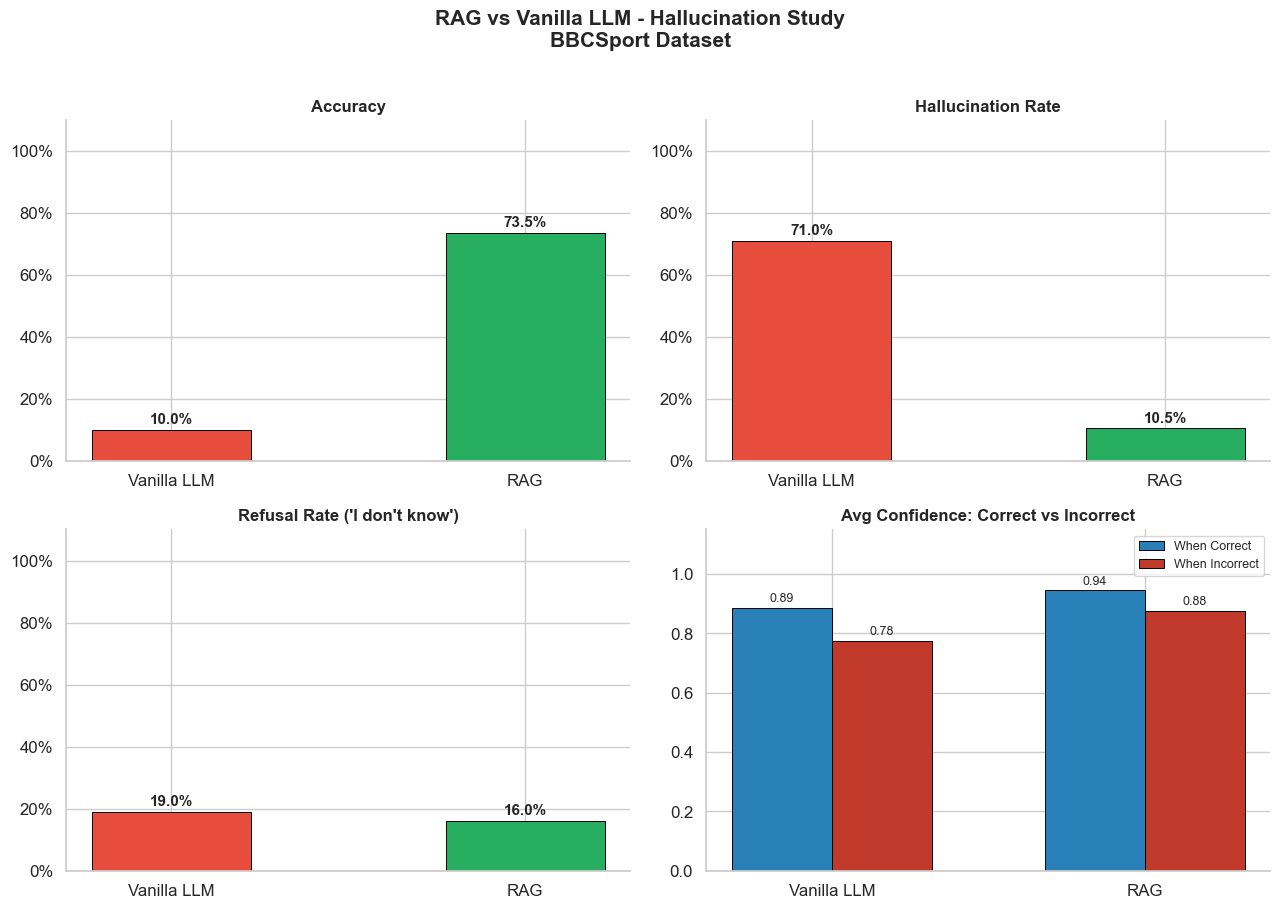

Chart saved: rag_vs_vanilla.png


In [11]:
def plot_results(metrics: Dict, save_path: str = 'rag_vs_vanilla.png') -> None:
    sns.set_theme(style='whitegrid', font_scale=1.1)
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(
        'RAG vs Vanilla LLM - Hallucination Study\nBBCSport Dataset',
        fontsize=15, fontweight='bold', y=1.01
    )
    systems = ['Vanilla LLM', 'RAG']
    palette = ['#E74C3C', '#27AE60']

    def bar_plot(ax, values, title, pct=True):
        bars = ax.bar(systems, values, color=palette, width=0.45, edgecolor='black', linewidth=0.7)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1.1 if pct else max(values) * 1.25)
        if pct:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
        for bar, val in zip(bars, values):
            lbl = f'{val:.1%}' if pct else f'{val:.2f}'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.01 if pct else 0.005),
                lbl, ha='center', va='bottom', fontsize=11, fontweight='bold'
            )
        ax.spines[['top', 'right']].set_visible(False)

    bar_plot(axes[0, 0], [metrics['vanilla']['accuracy'], metrics['rag']['accuracy']], 'Accuracy')
    bar_plot(axes[0, 1], [metrics['vanilla']['hallucination_rate'], metrics['rag']['hallucination_rate']], 'Hallucination Rate')
    bar_plot(axes[1, 0], [metrics['vanilla']['refusal_rate'], metrics['rag']['refusal_rate']], "Refusal Rate ('I don't know')")

    ax4 = axes[1, 1]
    x = np.arange(2)
    w = 0.32
    c_ok = [metrics['vanilla']['avg_conf_correct'], metrics['rag']['avg_conf_correct']]
    c_err = [metrics['vanilla']['avg_conf_incorrect'], metrics['rag']['avg_conf_incorrect']]
    b1 = ax4.bar(x - w / 2, c_ok, w, label='When Correct', color='#2980B9', edgecolor='black', linewidth=0.7)
    b2 = ax4.bar(x + w / 2, c_err, w, label='When Incorrect', color='#C0392B', edgecolor='black', linewidth=0.7)
    ax4.set_title('Avg Confidence: Correct vs Incorrect', fontsize=12, fontweight='bold')
    ax4.set_ylim(0, 1.15)
    ax4.set_xticks(x)
    ax4.set_xticklabels(systems)
    ax4.legend(fontsize=9)
    ax4.spines[['top', 'right']].set_visible(False)
    for bar in list(b1) + list(b2):
        ax4.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9
        )

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Chart saved: {save_path}')


plot_results(metrics)


### 8.1 Per-Category Breakdown

Break accuracy and hallucination rates down by sport category to identify which domains benefit most from RAG.

 Category  System  N  Accuracy  Hallucination Rate  Refusal Rate
athletics Vanilla 51     0.157               0.784         0.059
athletics     Rag 51     0.686               0.176         0.137
  cricket Vanilla 45     0.089               0.667         0.244
  cricket     Rag 45     0.711               0.111         0.178
 football Vanilla 32     0.125               0.719         0.156
 football     Rag 32     0.906               0.000         0.094
    rugby Vanilla 45     0.044               0.622         0.333
    rugby     Rag 45     0.644               0.133         0.222
   tennis Vanilla 27     0.074               0.778         0.148
   tennis     Rag 27     0.815               0.037         0.148


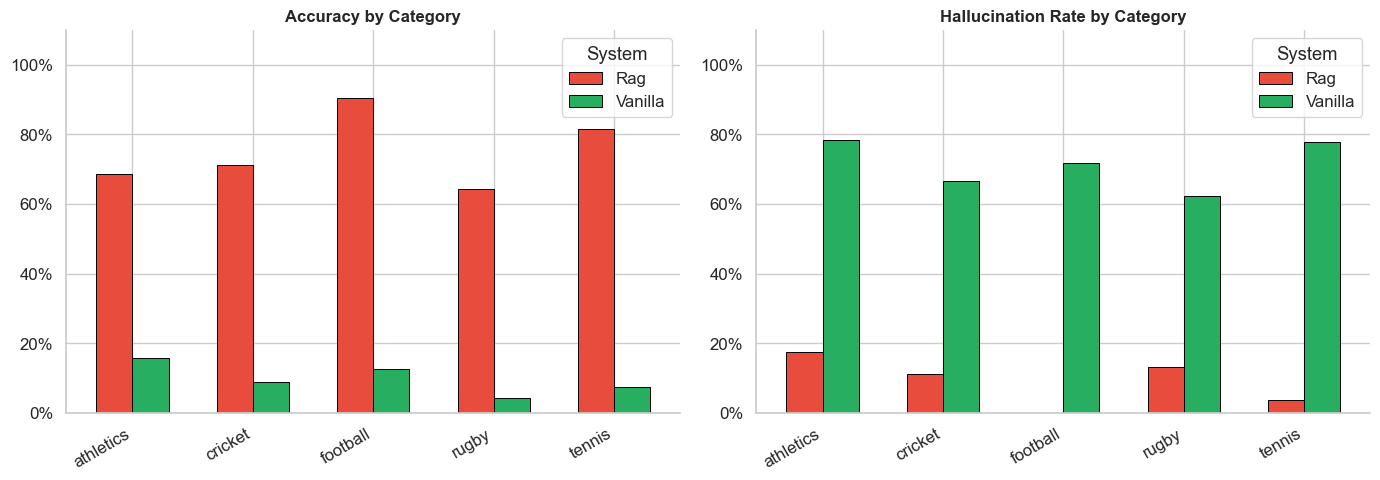

In [12]:
def per_category_metrics(results_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for cat in CATEGORIES:
        sub = results_df[results_df['category'] == cat]
        if len(sub) == 0:
            continue
        n = len(sub)
        for system in ('vanilla', 'rag'):
            preds = sub[f'{system}_answer'].tolist()
            truths = sub['true_answer'].tolist()
            correct = [is_correct(p, t) for p, t in zip(preds, truths)]
            refused = [is_refusal(p) for p in preds]
            halluc = [not c and not r for c, r in zip(correct, refused)]
            rows.append({
                'Category': cat,
                'System': system.capitalize(),
                'N': n,
                'Accuracy': round(sum(correct) / n, 3),
                'Hallucination Rate': round(sum(halluc) / n, 3),
                'Refusal Rate': round(sum(refused) / n, 3),
            })
    return pd.DataFrame(rows)


cat_df = per_category_metrics(results_df)
print(cat_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['Accuracy', 'Hallucination Rate']):
    pivot = cat_df.pivot(index='Category', columns='System', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#E74C3C', '#27AE60'], edgecolor='black', linewidth=0.7, width=0.6)
    ax.set_title(f'{metric} by Category', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_ylim(0, 1.1)
    ax.legend(title='System')
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('category_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 9 — Save Results & Final Summary

All outputs are saved to CSV for reproducibility and further analysis.

In [13]:
results_df.to_csv('full_evaluation_results.csv', index=False)
comparison_df.to_csv('metrics_comparison.csv', index=False)
cat_df.to_csv('category_metrics.csv', index=False)
corpus_df.to_csv('corpus_chunks.csv', index=False)

print('Saved: full_evaluation_results.csv, metrics_comparison.csv, category_metrics.csv, corpus_chunks.csv, qa_dataset.csv')

v, r = metrics['vanilla'], metrics['rag']

print('=' * 68)
print('FINAL RESEARCH SUMMARY - RAG vs Vanilla LLM on BBCSport')
print('=' * 68)
print(f'Dataset: BBCSport | {len(articles_df)} articles | 5 categories')
print(f'Corpus: {len(corpus_df)} chunks | 300-500 tokens each')
print(f'QA Set: {len(qa_df)} factual pairs | {TOP_K_CHUNKS} chunks retrieved')
print()
print(f'{"Metric":<35} {"Vanilla LLM":>13} {"RAG":>10} {"Delta":>10}')
print('-' * 70)
_KEY_METRICS = [
    ('accuracy', 'Accuracy'),
    ('hallucination_rate', 'Hallucination Rate'),
    ('refusal_rate', 'Refusal Rate'),
    ('overconfidence_gap', 'Overconfidence Gap'),
]
for key, label in _KEY_METRICS:
    vv, rv = v[key], r[key]
    delta = rv - vv
    sign = '+' if delta >= 0 else ''
    print(f'{label:<35} {vv:>12.1%} {rv:>9.1%} {sign}{delta:>8.1%}')
if r['retrieval_recall'] is not None:
    print(f'{"Retrieval Recall (RAG)":<35} {"N/A":>13} {r["retrieval_recall"]:>9.1%} {"N/A":>10}')
print()
improved = r['hallucination_rate'] < v['hallucination_rate']
print(f'RAG hallucination rate is {"LOWER" if improved else "HIGHER"} than Vanilla LLM')
print(f'RAG accuracy: {r["accuracy"]:.1%} vs Vanilla {v["accuracy"]:.1%}')
print(f'Overconfidence gap: RAG={r["overconfidence_gap"]:+.3f} Vanilla={v["overconfidence_gap"]:+.3f}')
print(f'Conclusion: RAG {"reduces" if improved else "does not reduce"} hallucination on BBCSport.')


Saved: full_evaluation_results.csv, metrics_comparison.csv, category_metrics.csv, corpus_chunks.csv, qa_dataset.csv
FINAL RESEARCH SUMMARY - RAG vs Vanilla LLM on BBCSport
Dataset: BBCSport | 737 articles | 5 categories
Corpus: 903 chunks | 300-500 tokens each
QA Set: 200 factual pairs | 3 chunks retrieved

Metric                                Vanilla LLM        RAG      Delta
----------------------------------------------------------------------
Accuracy                                   10.0%     73.5% +   63.5%
Hallucination Rate                         71.0%     10.5%   -60.5%
Refusal Rate                               19.0%     16.0%    -3.0%
Overconfidence Gap                        -11.0%     -6.9% +    4.1%
Retrieval Recall (RAG)                        N/A     70.5%        N/A

RAG hallucination rate is LOWER than Vanilla LLM
RAG accuracy: 73.5% vs Vanilla 10.0%
Overconfidence gap: RAG=-0.069 Vanilla=-0.110
Conclusion: RAG reduces hallucination on BBCSport.



# 🔹 Hybrid RAG Extension (Dense + BM25)

This section extends the analysis by adding:
- BM25 sparse retrieval
- Hybrid retrieval (Dense + Sparse)
- Hybrid RAG query function
- Extended evaluation metrics
- 3-system comparison plots

We now compare:
- Vanilla LLM
- Dense RAG
- Hybrid RAG


In [16]:
# python -m pip install rank-bm25
from rank_bm25 import BM25Okapi


In [17]:

# =========================
# Build BM25 Index
# =========================

print("Building BM25 index...")

tokenized_corpus = [
    chunk.split() for chunk in corpus_df['chunk_text'].tolist()
]

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 index built.")


Building BM25 index...
BM25 index built.


In [22]:

# =========================
# Hybrid Retrieval
# =========================

def retrieve_hybrid(question: str, k_dense: int = 5, k_sparse: int = 5, final_k: int = TOP_K_CHUNKS):

    # --- Dense retrieval ---
    dense_results = retrieve_chunks(question, k=k_dense)

    # --- Sparse retrieval ---
    tokenized_query = question.split()
    sparse_scores = bm25.get_scores(tokenized_query)
    top_sparse_idx = np.argsort(sparse_scores)[::-1][:k_sparse]

    sparse_results = [
        {
            'chunk_id': corpus_df.iloc[i]['chunk_id'],
            'chunk_text': corpus_df.iloc[i]['chunk_text'],
            'article_id': corpus_df.iloc[i]['article_id'],
            'similarity_score': float(sparse_scores[i]),
        }
        for i in top_sparse_idx
    ]

    # --- Combine & Deduplicate ---
    combined = dense_results + sparse_results

    seen = set()
    unique_chunks = []
    for c in combined:
        if c['chunk_id'] not in seen:
            unique_chunks.append(c)
            seen.add(c['chunk_id'])

    return unique_chunks[:final_k]


In [23]:
def run_hybrid_evaluation(results_df: pd.DataFrame) -> pd.DataFrame:
    hybrid_answers, hybrid_conf, chunk_id_lists = [], [], []
    for _, row in tqdm(results_df.iterrows(), total=len(results_df), desc="Hybrid RAG"):
        chunks = retrieve_hybrid(row["question"])
        res = query_rag(row["question"], chunks)
        hybrid_answers.append(res["model_answer"])
        hybrid_conf.append(res["confidence"])
        chunk_id_lists.append(json.dumps([c["chunk_id"] for c in chunks]))
        time.sleep(0.35)
    df = results_df.copy()
    df["hybrid_answer"] = hybrid_answers
    df["hybrid_confidence"] = hybrid_conf
    df["hybrid_chunk_ids"] = chunk_id_lists
    return df


logger.info("Starting Hybrid RAG evaluation...")
results_df = run_hybrid_evaluation(results_df)

print(f"Hybrid RAG evaluation complete: {len(results_df)} answers")
results_df[["question", "true_answer", "vanilla_answer", "rag_answer", "hybrid_answer"]].head(5)


2026-03-01 16:57:57,553 - INFO - Starting Hybrid RAG evaluation...
Hybrid RAG:   0%|          | 0/200 [00:00<?, ?it/s]2026-03-01 16:57:58,027 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-01 16:57:58,848 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Hybrid RAG:   0%|          | 1/200 [00:01<05:24,  1.63s/it]2026-03-01 16:57:59,686 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-01 16:58:00,194 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Hybrid RAG:   1%|          | 2/200 [00:02<04:48,  1.46s/it]2026-03-01 16:58:00,823 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-03-01 16:58:02,074 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Hybrid RAG:   2%|▏         | 3/200 [00:04<05:25,  1.65s/it]2026-03-01 16:58:02,689 - INFO - HTTP Request

Hybrid RAG evaluation complete: 200 answers


,question,true_answer,vanilla_answer,rag_answer,hybrid_answer
0,Who has been called in to coach Geraint Jones?,Jack Russell,There is no widely known information about a s...,Jack Russell,Jack Russell
1,Which team did Geraint Jones tour with in Sout...,England,Geraint Jones toured with the England cricket ...,England,England
2,Who is the England coach mentioned in the arti...,Duncan Fletcher,"I'm sorry, I don't have access to the article ...",Andy Robinson,Andy Robinson
3,Who said France can claim another Six Nations ...,Christophe Dominici,"Fabien Galthié, the head coach of the French n...",Christophe Dominici,Christophe Dominici
4,What was the score in France's win against Eng...,18-17,The score in France's win against England in t...,18-17,18-17


In [24]:
def compute_three_system_metrics(results_df: pd.DataFrame, corpus_df: pd.DataFrame) -> Dict:
    n = len(results_df)
    system_map = {
        "Vanilla LLM": ("vanilla_answer", "vanilla_confidence", None),
        "RAG":         ("rag_answer",     "rag_confidence",     "retrieved_chunk_ids"),
        "Hybrid RAG":  ("hybrid_answer",  "hybrid_confidence",  "hybrid_chunk_ids"),
    }
    out: Dict = {}
    for label, (ans_col, conf_col, chunk_col) in system_map.items():
        preds  = results_df[ans_col].tolist()
        truths = results_df["true_answer"].tolist()
        confs  = results_df[conf_col].tolist()
        correct = [is_correct(p, t) for p, t in zip(preds, truths)]
        refused = [is_refusal(p) for p in preds]
        halluc  = [not c and not r for c, r in zip(correct, refused)]
        conf_ok  = [confs[i] for i in range(n) if correct[i]]
        conf_err = [confs[i] for i in range(n) if halluc[i]]
        avg_ok  = float(np.mean(conf_ok))  if conf_ok  else 0.0
        avg_err = float(np.mean(conf_err)) if conf_err else 0.0
        entry = {
            "accuracy":          round(sum(correct) / n, 4),
            "hallucination_rate": round(sum(halluc)  / n, 4),
            "refusal_rate":       round(sum(refused) / n, 4),
            "avg_conf_correct":   round(avg_ok,  4),
            "avg_conf_incorrect": round(avg_err, 4),
        }
        if chunk_col and chunk_col in results_df.columns:
            recall = [
                retrieval_recall(row["true_answer"], row[chunk_col], corpus_df)
                for _, row in results_df.iterrows()
            ]
            entry["retrieval_recall"] = round(sum(recall) / n, 4)
        else:
            entry["retrieval_recall"] = None
        out[label] = entry
    return out


three_metrics = compute_three_system_metrics(results_df, corpus_df)

rows = []
for sys_label, m in three_metrics.items():
    rows.append({
        "System":             sys_label,
        "Accuracy":           m["accuracy"],
        "Hallucination Rate": m["hallucination_rate"],
        "Refusal Rate":       m["refusal_rate"],
        "Retrieval Recall":   m["retrieval_recall"] if m["retrieval_recall"] is not None else "N/A",
    })

three_df = pd.DataFrame(rows)
print(three_df.to_string(index=False))


     System  Accuracy  Hallucination Rate  Refusal Rate Retrieval Recall
Vanilla LLM     0.100               0.710          0.19              N/A
        RAG     0.735               0.105          0.16            0.705
 Hybrid RAG     0.725               0.115          0.16            0.705


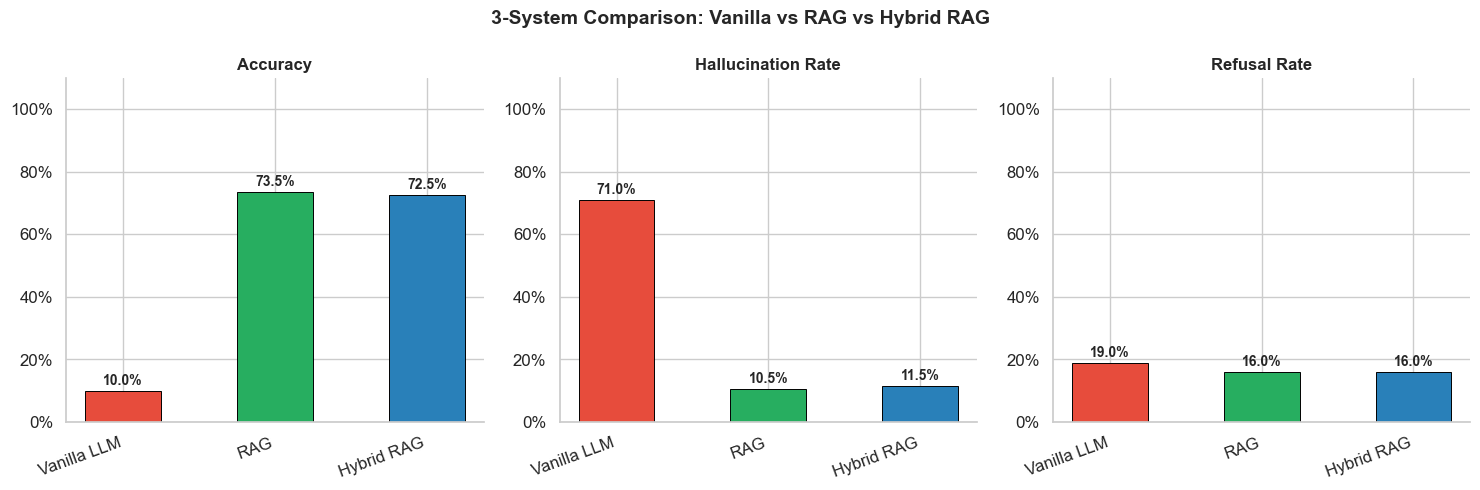

Chart saved: three_system_comparison.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("3-System Comparison: Vanilla vs RAG vs Hybrid RAG", fontsize=14, fontweight="bold")

sys_labels = list(three_metrics.keys())
palette    = ["#E74C3C", "#27AE60", "#2980B9"]

for ax, (metric_key, title) in zip(axes, [
    ("accuracy",          "Accuracy"),
    ("hallucination_rate", "Hallucination Rate"),
    ("refusal_rate",       "Refusal Rate"),
]):
    values = [three_metrics[s][metric_key] for s in sys_labels]
    bars = ax.bar(sys_labels, values, color=palette, edgecolor="black", linewidth=0.7, width=0.5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_xticklabels(sys_labels, rotation=20, ha="right")
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold"
        )

plt.tight_layout()
plt.savefig("three_system_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: three_system_comparison.png")
